# 02 · Aproximem π: del triangle als 300 costats

[Obre aquest quadern a Google Colab](https://colab.research.google.com/github/mlacasa/1BATXILLERAT/blob/main/C%C3%A0lcul_Nombre_pi.ipynb)

**Matemàtiques · 1r de batxillerat**  
**Autoria: Dr. Lacasa-Cazcarra · Any 2026**

**Objectiu.** Calcular pas a pas el costat d'un polígon regular i veure com el seu perímetre permet aproximar π, de 3 a 300 costats.

**Abans de començar:** perímetres, angles, Pitàgores i sinus d'un angle agut (el repassem aquí)  
**Temps orientatiu:** 1 sessió. Hi ha activitats bàsiques i ampliacions opcionals.

**Funcionament.** Executa les cel·les en ordre, des del començament. Primer fes una predicció,
després experimenta i escriu una justificació. Els controls són opcionals: també pots
modificar els arguments de les funcions i executar-les. Les figures representen mostres
finites; les propietats infinites necessiten una demostració.

**Procedència.** Reelaboració de Càlcul_Nombre_pi.ipynb amb construccions geomètriques i gràfics propis.


In [1]:
import math
from fractions import Fraction
from decimal import Decimal, localcontext
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

plt.rcParams.update({"figure.figsize": (10, 4), "axes.grid": True,
                     "font.size": 11, "figure.dpi": 100})

def explora(funcio, **rangs):
    """Controls opcionals: la mateixa funció també es pot cridar directament."""
    # Conservem un exemple estàtic per als lectors sense controls interactius.
    funcio()
    try:
        import ipywidgets as widgets
    except ImportError:
        print("Sense controls: executem els paràmetres per defecte. Pots canviar-los a la crida.")
        return None
    panell = widgets.interactive(funcio, **rangs)
    display(panell)
    return panell


## Ruta guiada per a 1r de batxillerat

**Pregunta de partida:** Si cada costat es fa més curt, per què el perímetre augmenta?

**Al final ho has de poder explicar:** Relacionar el moviment del polígon amb els angles, el costat, el perímetre i l'error de π.

La primera lectura combina l'exemple resolt amb el **laboratori animat** i les preguntes
que l'acompanyen. Els apartats marcats com a ampliació formal aprofundeixen en el rigor;
no cal entendre tot el codi per interpretar la matemàtica.

Dedica 2 minuts a una predicció escrita, 8–10 minuts a experimentar i pausar,
i 5 minuts a justificar una conclusió amb càlculs. Després resol el repte amb dades noves.
L'animació té controls de reproducció, pausa i selecció de fotograma.
Si el visor no mostra HTML interactiu, el fotograma estàtic i la funció
`fotograma_laboratori(...)` permeten fer la mateixa activitat pas a pas després d'executar el codi.


## 1. La idea: substituir una corba per segments

Dibuixem un **polígon regular inscrit** en una circumferència de radi $r$:
tots els costats són iguals i tots els vèrtexs són sobre la circumferència.
Si $b$ és la longitud d'un costat i $n$ el nombre de costats, el perímetre és
$p_n=n\,b$. La longitud de la circumferència és $C=2\pi r$.

Els segments queden per dins dels arcs: $p_n<C$. Quan augmentem $n$, el perímetre
del polígon s'apropa a la longitud de la circumferència. Per tant,

$$\boxed{\pi\approx\pi_n=\frac{p_n}{2r}=\frac{n\,b}{2r}}.$$

**Treballarem amb $r=1$**, de manera que $\pi_n=p_n/2$. El símbol $\pi_n$
designa la nostra aproximació amb $n$ costats, no el valor exacte de $\pi$.
Acceptem aquí la comparació geomètrica entre arcs i perímetres.

**Abans d'executar:** amb més costats, cada costat serà més llarg o més curt?
I el perímetre total? Escriu una predicció: són dues preguntes diferents.


## 2. L'angle superior del triangle isòsceles

**Pas 1.** Unim el centre $O$ amb dos vèrtexs consecutius $A$ i $B$.
El triangle $OAB$ és isòsceles perquè $OA=OB=r$: tots dos segments són radis.
La base $AB=b$ és precisament un costat del polígon.

**Pas 2.** Al voltant d'$O$ hi ha $n$ triangles iguals que reparteixen una volta completa:

$$n\alpha=360^\circ\qquad\Longrightarrow\qquad
\boxed{\alpha=\frac{360^\circ}{n}}.$$

Aquest és l'**angle superior** del triangle al dibuix, situat al centre del cercle.
No és l'angle interior del polígon en un vèrtex.

**Pas 3.** Tracem l'altura des d'$O$ fins al punt mig $M$ de la base.
En un triangle isòsceles, aquesta altura també parteix l'angle superior per la meitat.
Obtenim dos triangles rectangles iguals:

$$\boxed{\beta=\frac{\alpha}{2}=\frac{180^\circ}{n}},\qquad
AM=MB=\frac b2,\qquad OM\perp AB.$$


## 3. Com calculem la base, pas a pas?

Mirem només el triangle rectangle $OMB$:

1. La **hipotenusa** és $OB=r$ (el costat oposat a l'angle recte).
2. El **catet oposat** a $\beta$ és $MB=b/2$.
3. Per definició del sinus, $\sin\beta=\text{catet oposat}/\text{hipotenusa}$.
4. Substituïm les longituds: $\sin\beta=(b/2)/r$.
5. Multipliquem per $r$: $r\sin\beta=b/2$. Encara tenim **mitja base**.
6. Multipliquem per $2$ per obtenir **tota la base**:

$$\boxed{b=2r\sin\beta=2r\sin\left(\frac{180^\circ}{n}\right)}.$$

**Si ho comproves amb calculadora, posa-la en mode DEG (graus).**
No confonguis $\alpha$ amb $\beta$ ni $b$ amb $b/2$.

La ruta completa del càlcul és:

$$n\ \longrightarrow\ \alpha=\frac{360^\circ}{n}
\ \longrightarrow\ \beta=\frac{\alpha}{2}
\ \longrightarrow\ b=2r\sin\beta
\ \longrightarrow\ p_n=n b
\ \longrightarrow\ \pi_n=\frac{p_n}{2r}.$$


### Com ho calcularà l'ordinador sense conèixer π?

Per trobar la base, el codi aproxima la posició del vèrtex dividint angles
per la meitat i aplicant Pitàgores. Això permet treballar amb **qualsevol nombre
enter de costats de 3 a 300**, sense introduir el valor de π en el càlcul.
Pots seguir els dibuixos i els resultats sense estudiar aquest codi auxiliar.

<details><summary>Ampliació opcional: bisecció geomètrica d'un angle</summary>

En un cercle de radi 1, els punts $(1,0)$ i $(0,1)$ delimiten un angle de $90^\circ$.
El punt mig de la corda està sobre la bisectriu. El dividim per la seva distància
a l'origen, calculada amb Pitàgores, per tornar-lo a situar sobre el cercle.
Així obtenim la direcció de $45^\circ$. Conservem la meitat que conté l'angle
buscat i repetim. La coordenada vertical del punt obtingut aproxima el sinus.

Fem 50 biseccions. Les operacions tenen arrodoniment: aquests resultats són
aproximacions numèriques, no intervals certificats. `math.pi` s'utilitzarà
**només després**, com a referència al gràfic i per comparar l'error.
La trigonometria de NumPy només serveix per dibuixar les figures.

</details>


In [2]:
def sinus_geometric(graus):
    """Aproxima el sinus d'un angle entre 0 i 90 graus sense usar π."""
    if not math.isfinite(graus) or not 0 <= graus <= 90:
        raise ValueError("Cal un angle entre 0 i 90 graus.")
    if graus == 0:
        return 0.0
    if graus == 90:
        return 1.0
    angle_a, angle_b = 0.0, 90.0
    ax, ay, bx, by = 1.0, 0.0, 0.0, 1.0
    for _ in range(50):
        angle_m = (angle_a + angle_b) / 2
        mx, my = (ax + bx) / 2, (ay + by) / 2
        distancia = math.sqrt(mx * mx + my * my)  # Pitàgores
        mx, my = mx / distancia, my / distancia
        if angle_m == graus:
            return my
        if angle_m < graus:
            angle_a, ax, ay = angle_m, mx, my
        else:
            angle_b, bx, by = angle_m, mx, my
    return (ay + by) / 2

def dades_poligon(n, radi=1.0):
    """Angles, costat, perímetre i aproximació de π d'un polígon inscrit."""
    if isinstance(n, bool) or not isinstance(n, (int, np.integer)) or not 3 <= n <= 300:
        raise ValueError("El nombre de costats ha de ser un enter de 3 a 300.")
    if not math.isfinite(radi) or radi <= 0:
        raise ValueError("El radi ha de ser positiu i finit.")
    alpha = 360.0 / n
    beta = alpha / 2
    mitja_base = radi * sinus_geometric(beta)
    base = 2 * mitja_base
    perimetre = n * base
    pi_aprox = perimetre / (2 * radi)
    altura = math.sqrt(radi**2 - mitja_base**2)
    return dict(n=n, radi=radi, alpha=alpha, beta=beta, base=base,
                altura=altura, perimetre=perimetre, pi_aprox=pi_aprox)


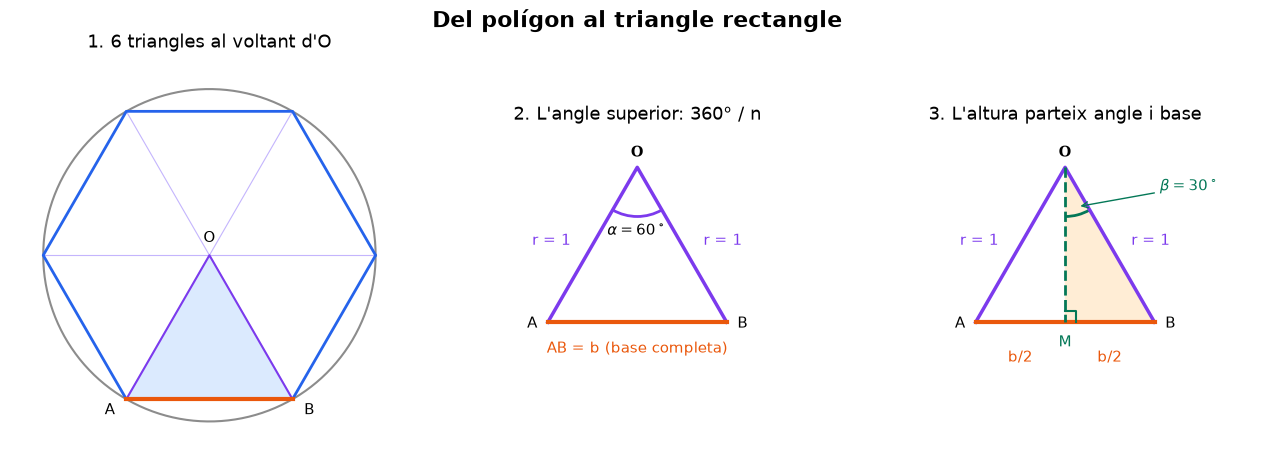

In [3]:
from matplotlib.patches import Arc, Polygon

def dibuixa_poligon(ax, n):
    # π i les funcions trigonomètriques només orienten aquest DIBUIX.
    theta = np.linspace(0, 2*np.pi, 600)
    angles = np.linspace(0, 2*np.pi, n+1) - np.pi/2 - np.pi/n
    x, y = np.cos(angles), np.sin(angles)
    ax.plot(np.cos(theta), np.sin(theta), color="0.55", lw=1.5)
    ax.plot(x, y, color="#2563eb", lw=2)
    if n <= 24:
        for vx, vy in zip(x[:-1], y[:-1]):
            ax.plot([0, vx], [0, vy], color="#c4b5fd", lw=.8, zorder=0)
    ax.fill([0, x[0], x[1]], [0, y[0], y[1]], color="#dbeafe")
    ax.plot([x[0], 0, x[1]], [y[0], 0, y[1]], color="#7c3aed", lw=1.5)
    ax.plot(x[:2], y[:2], color="#ea580c", lw=3)
    if n <= 24:
        ax.text(x[0]-.07, y[0]-.09, "A", ha="right")
        ax.text(x[1]+.07, y[1]-.09, "B", ha="left")
    ax.text(0, .08, "O", ha="center")
    ax.set(aspect="equal", xlim=(-1.2, 1.2), ylim=(-1.25, 1.2))
    ax.axis("off")

def dibuixa_triangle(n=6):
    d = dades_poligon(n)
    s, h, beta = d["base"]/2, d["altura"], d["beta"]
    fig, axes = plt.subplots(1, 3, figsize=(13, 4.8))
    dibuixa_poligon(axes[0], n)
    axes[0].set_title(f"1. {n} triangles al voltant d'O")
    for ax in axes[1:]:
        ax.plot([-s, 0, s], [-h, 0, -h], color="#7c3aed", lw=2.5)
        ax.plot([-s, s], [-h, -h], color="#ea580c", lw=3)
        ax.text(0, .06, "O", ha="center", weight="bold")
        ax.text(-s-.06, -h-.03, "A", ha="right")
        ax.text(s+.06, -h-.03, "B", ha="left")
        ax.text(-s/2-.12, -h/2, "r = 1", ha="right", color="#7c3aed")
        ax.text(s/2+.12, -h/2, "r = 1", ha="left", color="#7c3aed")
        ax.set(aspect="equal", xlim=(-1.15, 1.15), ylim=(-1.25, .22))
        ax.axis("off")
    ax = axes[1]
    ax.add_patch(Arc((0, 0), .55, .55, theta1=-90-beta,
                     theta2=-90+beta, color="#7c3aed", lw=2))
    ax.text(0, -.38, rf"$\alpha={d['alpha']:g}^\circ$", ha="center")
    ax.text(0, -h-.17, "AB = b (base completa)", ha="center", color="#ea580c")
    ax.set_title("2. L'angle superior: 360° / n")
    ax = axes[2]
    ax.add_patch(Polygon([[0, 0], [0, -h], [s, -h]], color="#ffedd5", zorder=0))
    ax.plot([0, 0], [0, -h], "--", color="#047857", lw=2)
    q = min(.06, s/3, h/5)
    ax.plot([0, q, q], [-h+q, -h+q, -h], color="#047857")
    ax.add_patch(Arc((0, 0), .55, .55, theta1=-90,
                     theta2=-90+beta, color="#047857", lw=2))
    ax.annotate(rf"$\beta={beta:g}^\circ$", xy=(.07, -.22),
                xytext=(.53, -.13), arrowprops=dict(arrowstyle="->", color="#047857"),
                color="#047857")
    ax.text(0, -h-.07, "M", ha="center", va="top", color="#047857")
    ax.text(-s/2, -h-.22, "b/2", ha="center", color="#ea580c")
    ax.text(s/2, -h-.22, "b/2", ha="center", color="#ea580c")
    ax.set_title("3. L'altura parteix angle i base")
    fig.suptitle("Del polígon al triangle rectangle", fontsize=16, weight="bold")
    fig.tight_layout()
    plt.show()

dibuixa_triangle(6)


### Exemple complet: primer 6 costats, després 12

| Pas | Hexàgon: $n=6$, $r=1$ | Dodecàgon: $n=12$, $r=1$ |
|---|---|---|
| Angle superior $\alpha=360^\circ/n$ | $60^\circ$ | $30^\circ$ |
| Mig angle $\beta=\alpha/2$ | $30^\circ$ | $15^\circ$ |
| Mitja base $b/2=r\sin\beta$ | $\sin30^\circ=0{,}5$ | $\sin15^\circ\approx0{,}258819$ |
| Base completa $b$ | $1$ | $\approx0{,}517638$ |
| Perímetre $p_n=n b$ | $6$ | $\approx6{,}211657$ |
| Aproximació $\pi_n=p_n/2$ | $3$ | $\approx3{,}105829$ |

**Conclusió:** en passar de 6 a 12 costats, la base disminueix, però el perímetre
augmenta i l'aproximació s'acosta a π. Conservem tots els decimals durant el
càlcul i arrodonim només en mostrar el resultat.

**Una comprovació amb Pitàgores, sense sinus:** l'altura de l'hexàgon és
$OM=\sqrt{1^2-(1/2)^2}=\sqrt3/2$. Sigui $D$ el punt de la circumferència
entre $A$ i $B$, sobre la prolongació d'$OM$. Tenim $MD=1-\sqrt3/2$.
En el triangle rectangle $AMD$,

$$AD=\sqrt{AM^2+MD^2}
=\sqrt{(1/2)^2+(1-\sqrt3/2)^2}
=\sqrt{2-\sqrt3}\approx0{,}517638.$$

$AD$ és el costat del polígon de 12 costats: coincideix amb el càlcul anterior.


## 4. Tots els nombres de costats, de 3 a 300

Ara repetim **exactament els mateixos passos** per a cada enter $n=3,4,5,\ldots,300$.
La corba blava mostra $\pi_n=p_n/2$; la línia discontínua és el valor conegut de π,
utilitzat només com a referència. Els segments uneixen resultats per a nombres
enters de costats.

- **Esquerra:** observa que les aproximacions creixen i s'acosten a π des de sota.
- **Centre:** ampliem la zona de 50 a 300 costats per veure que encara queda una separació.
- **Dreta:** mostrem l'error $\pi-\pi_n$ en escala logarítmica; baixar una divisió
  principal significa dividir l'error per 10.


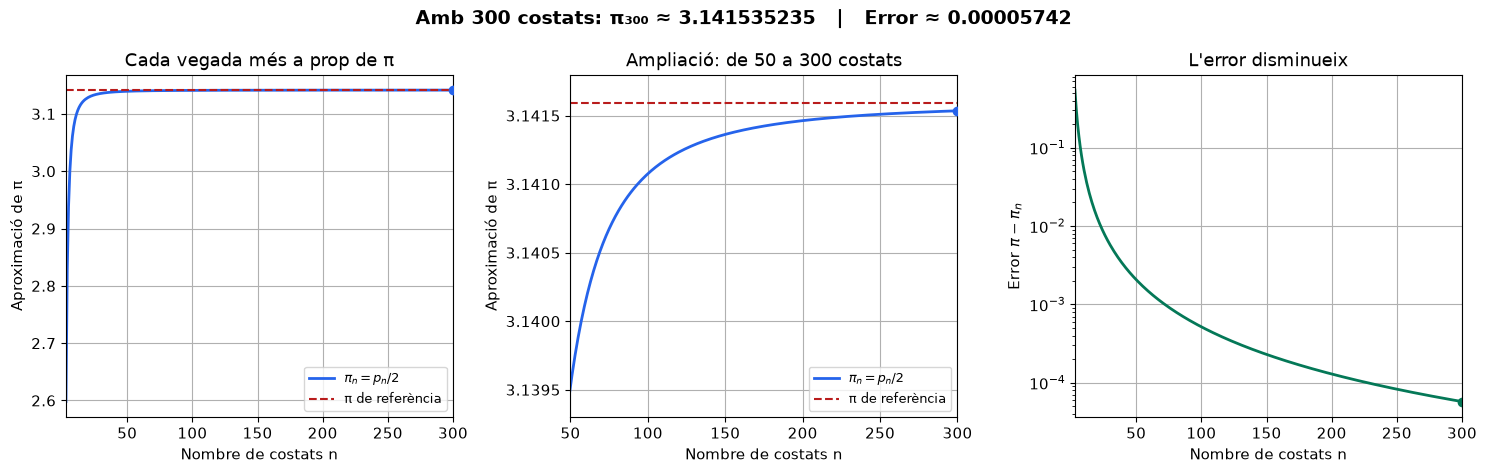

In [4]:
costats = np.arange(3, 301)  # 301 no s'inclou: l'últim polígon té 300 costats.
aproximacions = np.array([dades_poligon(int(n))["pi_aprox"] for n in costats])
pi_referencia = math.pi  # Només comparació; no calcula cap costat ni perímetre.
errors = pi_referencia - aproximacions

fig, axes = plt.subplots(1, 3, figsize=(15, 4.8))
for ax in axes[:2]:
    ax.plot(costats, aproximacions, color="#2563eb", lw=2, label=r"$\pi_n=p_n/2$")
    ax.axhline(pi_referencia, color="#b91c1c", ls="--", label="π de referència")
    ax.scatter([300], [aproximacions[-1]], color="#2563eb", zorder=5)
    ax.set(xlabel="Nombre de costats n", ylabel="Aproximació de π")
    ax.ticklabel_format(axis="y", style="plain", useOffset=False)
    ax.legend(loc="lower right", fontsize=9)
axes[0].set(xlim=(3, 300), title="Cada vegada més a prop de π")
axes[1].set(xlim=(50, 300), ylim=(3.1393, 3.1418), title="Ampliació: de 50 a 300 costats")
axes[2].semilogy(costats, errors, color="#047857", lw=2)
axes[2].scatter([300], [errors[-1]], color="#047857")
axes[2].set(xlim=(3, 300), xlabel="Nombre de costats n",
            ylabel=r"Error $\pi-\pi_n$", title="L'error disminueix")
fig.suptitle(f"Amb 300 costats: π₃₀₀ ≈ {aproximacions[-1]:.9f}   |   Error ≈ {errors[-1]:.8f}",
             fontsize=14, weight="bold")
fig.tight_layout()
plt.show()


In [5]:
seleccio = [3, 4, 6, 12, 24, 48, 96, 192, 300]
files = ["| Costats n | α (graus) | β (graus) | Base b | Perímetre pₙ | Aproximació πₙ | Error |",
         "|---:|---:|---:|---:|---:|---:|---:|"]
for n in seleccio:
    d = dades_poligon(n)
    files.append(f"| {n} | {d['alpha']:.3f} | {d['beta']:.3f} | {d['base']:.8f} | "
                 f"{d['perimetre']:.8f} | {d['pi_aprox']:.8f} | {math.pi-d['pi_aprox']:.8f} |")
display(Markdown("\n".join(files)))


| Costats n | α (graus) | β (graus) | Base b | Perímetre pₙ | Aproximació πₙ | Error |
|---:|---:|---:|---:|---:|---:|---:|
| 3 | 120.000 | 60.000 | 1.73205081 | 5.19615242 | 2.59807621 | 0.54351644 |
| 4 | 90.000 | 45.000 | 1.41421356 | 5.65685425 | 2.82842712 | 0.31316553 |
| 6 | 60.000 | 30.000 | 1.00000000 | 6.00000000 | 3.00000000 | 0.14159265 |
| 12 | 30.000 | 15.000 | 0.51763809 | 6.21165708 | 3.10582854 | 0.03576411 |
| 24 | 15.000 | 7.500 | 0.26105238 | 6.26525723 | 3.13262861 | 0.00896404 |
| 48 | 7.500 | 3.750 | 0.13080626 | 6.27870041 | 3.13935020 | 0.00224245 |
| 96 | 3.750 | 1.875 | 0.06543817 | 6.28206390 | 3.14103195 | 0.00056070 |
| 192 | 1.875 | 0.938 | 0.03272346 | 6.28290494 | 3.14145247 | 0.00014018 |
| 300 | 1.200 | 0.600 | 0.02094357 | 6.28307047 | 3.14153523 | 0.00005742 |

**Llegeix l'última fila:** amb 300 costats, $\alpha=1{,}2^\circ$ i $\beta=0{,}6^\circ$.
La base és aproximadament $0{,}02094357$ i el perímetre $6{,}28307047$.
Així obtenim $\pi_{300}\approx3{,}141535235$, amb un error d'uns $0{,}00005742$.
**No hem obtingut π exactament.** Arrodonint a tres decimals, tant $\pi_{300}$
com π donen $3{,}142$; a quatre decimals encara difereixen: $3{,}1415$ i $3{,}1416$.


## Laboratori animat · observa, atura i explica


### Una pel·lícula del polígon i del seu resultat

L'animació uneix dues representacions del mateix càlcul. A l'esquerra augmenta el nombre
de costats; a la dreta apareix la seva aproximació de π. El punt taronja correspon sempre
al polígon visible. L'eix vertical dret està ampliat: els primers valors queden per sota
de la finestra i entren al gràfic quan l'aproximació és prou propera a π.

**Prediu.** En passar de 6 a 12 costats, l'angle central i el costat es redueixen exactament
a la meitat? Són dues preguntes diferents: comprova-les amb els valors de la taula.
**Pausa** a 6, 12 i 300 costats. Anota $\alpha$, $b$ i $\pi_n$. Explica el factor 2 a $b=2\sin(\alpha/2)$.

La pel·lícula mostra una selecció de nombres de costats per ser llegible;
la corba es calcula per a **tots els enters de 3 a 300**.


In [6]:
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

def fotograma_laboratori(pas):
    """Mostra un estat quiet per poder llegir, dibuixar i prendre apunts."""
    fig, axes = plt.subplots(1, 2, figsize=(11.6, 4.7), dpi=90)
    dibuixa_laboratori(pas, axes)
    fig.suptitle(titol_laboratori, fontsize=14, weight="bold")
    fig.tight_layout(rect=(0, 0, 1, .92))
    plt.show()

def anima_laboratori():
    """Animació HTML amb pausa i desplaçament manual; no necessita FFmpeg."""
    fig, axes = plt.subplots(1, 2, figsize=(11.6, 4.7), dpi=80)
    def actualitza(pas):
        for ax in axes:
            ax.clear()
        dibuixa_laboratori(pas, axes)
        fig.suptitle(titol_laboratori, fontsize=14, weight="bold")
        fig.tight_layout(rect=(0, 0, 1, .92))
    animacio = FuncAnimation(fig, actualitza, frames=fotogrames_laboratori,
                             interval=700, repeat=False, cache_frame_data=False)
    try:
        contingut = animacio.to_jshtml(fps=1.5, default_mode="once")
    finally:
        plt.close(fig)
    return HTML(contingut)


In [7]:
titol_laboratori = "Del polígon al nombre: aproximar π"
fotogrames_laboratori = [3, 4, 5, 6, 8, 10, 12, 16, 20, 24, 30, 40, 50, 65, 80, 100, 125, 150, 200, 250, 300]

def dibuixa_laboratori(n, axes):
    d = dades_poligon(n)
    ax, bx = axes
    dibuixa_poligon(ax, n)
    ax.set_title(f"n = {n}; α = {d['alpha']:.3f}°; β = {d['beta']:.3f}°\n"
                 f"Base ≈ {d['base']:.6f}; perímetre ≈ {d['perimetre']:.6f}")
    ns = np.arange(3, 301)
    ys = np.array([dades_poligon(int(k))["pi_aprox"] for k in ns])
    bx.plot(ns, ys, color="0.8", label="Recorregut complet")
    bx.plot(ns[ns <= n], ys[ns <= n], color="#2563eb", lw=2)
    bx.axhline(math.pi, color="#b91c1c", ls="--", label="π de referència")
    if d["pi_aprox"] >= 3.12:
        bx.scatter([n], [d["pi_aprox"]], color="#ea580c", s=65, zorder=5)
    else:
        bx.text(.5, .2, "El valor encara és per sota de 3,12", transform=bx.transAxes,
                ha="center", color="#ea580c")
    bx.set(xlim=(3, 305), ylim=(3.12, 3.143), xlabel="Nombre de costats", ylabel="Aproximació (escala ampliada)",
           title=f"πₙ ≈ {d['pi_aprox']:.9f}\nError ≈ {math.pi-d['pi_aprox']:.8f}")
    bx.ticklabel_format(axis="y", style="plain", useOffset=False)
    bx.legend(loc="lower right", fontsize=8)


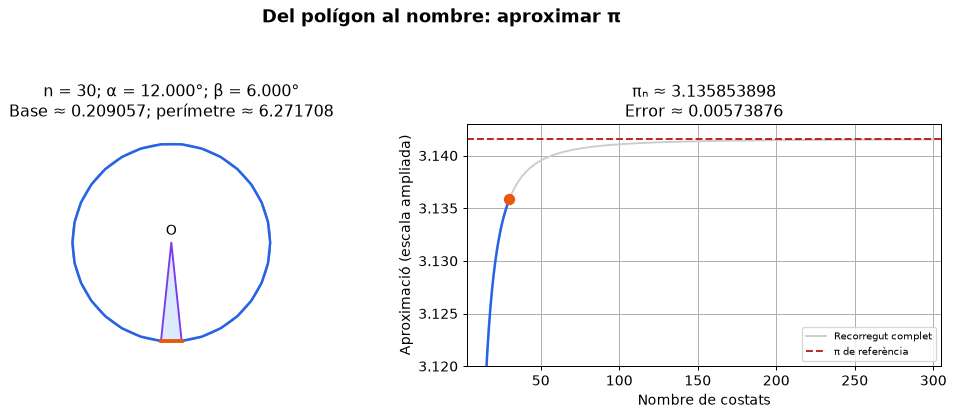

In [8]:
# Fotograma visible també quan no es reprodueix l'animació.
fotograma_laboratori(fotogrames_laboratori[len(fotogrames_laboratori)//2])


**Ara reprodueix l'animació.** Fes servir la pausa i el control de fotograma per contrastar la teva predicció. Els valors numèrics dels títols formen part de l'explicació.


In [9]:
display(anima_laboratori())


### Compara abans de concloure

Compara 6 i 300 costats: anota angle central, base i perímetre. Després compara 100 i 200. La segona aproximació redueix l'error aproximadament a la meitat o a la quarta part?

Tria dos estats amb els controls i prem **Compara els estats**. Llegeix les escales: algunes ampliacions del laboratori canvien els límits dels eixos. Justifica la comparació amb els nombres dels títols.


In [10]:
parella_comparacio = (6, 300)
etiquetes_comparacio = [f"{n} costats" for n in fotogrames_laboratori]
preguntes_taller = [{'enunciat': 'Amb 12 costats, quin angle usem per calcular mitja base amb el sinus?', 'opcions': ['30°', '15°', '150°'], 'correcta': 1, 'retorn': ["30° és l'angle central complet. L'altura el divideix en dos.", 'Correcte: 360°/12 = 30° i la meitat és 15°.', "150° és l'angle interior del dodecàgon, no el mig angle del triangle central."]}, {'enunciat': 'Si el radi es duplica, què passa amb pₙ/(2r)?', 'opcions': ['Es conserva', 'Es duplica', 'Es divideix per 2'], 'correcta': 0, 'retorn': ['Correcte: tant el perímetre com el diàmetre es dupliquen.', 'El numerador es duplica, però el denominador també.', 'El denominador es duplica, però el perímetre no es manté fix.']}, {'enunciat': 'Amb 300 costats, el polígon sembla un cercle. Què significa?', 'opcions': ['Ja hem obtingut π exactament', "L'error és exactament zero", 'La resolució del dibuix amaga una diferència petita'], 'correcta': 2, 'retorn': ['Un polígon finit encara té segments: la semblança visual no és una igualtat.', "La taula mostra un error positiu d'aproximadament 0,00005742.", "Correcte: cal llegir l'error o ampliar el gràfic, a més de mirar la forma."]}]


In [11]:
def compara_estats(inicial, final):
    """Dos fotogrames simultanis; els eixos conserven el significat del laboratori."""
    if inicial not in fotogrames_laboratori or final not in fotogrames_laboratori:
        raise ValueError("Tria dos estats de fotogrames_laboratori.")
    fig, axes = plt.subplots(2, 2, figsize=(11.6, 8.8), dpi=90)
    for fila, estat, lletra in [(0, inicial, "A"), (1, final, "B")]:
        dibuixa_laboratori(estat, axes[fila])
        for ax in axes[fila]:
            ax.set_title(lletra + " · " + ax.get_title(), fontsize=10)
    fig.suptitle("Comparació simultània: observa què canvia i què es conserva", fontsize=14, weight="bold")
    fig.tight_layout(rect=(0, 0, 1, .95), h_pad=3)
    plt.show()

def controls_comparacio():
    try:
        import ipywidgets as widgets
    except ImportError:
        print("Canvia els dos arguments de compara_estats(...) per fer una altra comparació.")
        return None
    opcions = list(zip(etiquetes_comparacio, fotogrames_laboratori))
    panell = widgets.interactive(compara_estats, {"manual": True, "manual_name": "Compara els estats"},
        inicial=widgets.Dropdown(options=opcions, value=parella_comparacio[0], description="Estat A:"),
        final=widgets.Dropdown(options=opcions, value=parella_comparacio[1], description="Estat B:"))
    display(panell)
    return panell

def feedback_resposta(numero, lletra):
    """Retorn per opció. Ex.: feedback_resposta(1, 'B'); no desa ni envia respostes."""
    if isinstance(numero, bool) or not isinstance(numero, int) or not 1 <= numero <= len(preguntes_taller):
        raise ValueError("El número de pregunta no és vàlid.")
    q = preguntes_taller[numero-1]
    lletra = str(lletra).strip().upper()
    lletres = "ABCDEFGHIJKLMNOPQRSTUVWXYZ"[:len(q["opcions"])]
    if lletra not in lletres or len(lletra) != 1:
        raise ValueError("Tria una de les lletres de les opcions.")
    index = lletres.index(lletra)
    return {"correcte": index == q["correcta"], "explicacio": q["retorn"][index]}

def mostra_feedback(numero, lletra):
    resultat = feedback_resposta(numero, lletra)
    estat = "Resposta encertada" if resultat["correcte"] else "Revisa el raonament"
    display(Markdown(f"**Pregunta {numero} · {estat}.** {resultat['explicacio']}"))
    return resultat

def crea_autoavaluacio():
    try:
        import ipywidgets as widgets
        from html import escape
    except ImportError:
        print("Respon amb mostra_feedback(1, 'A'), canviant la pregunta i la lletra.")
        return None
    camps, selectors = [], []
    for numero, q in enumerate(preguntes_taller, 1):
        opcions = [("Tria una resposta", None)] + [
            (f"{chr(65+k)}. {text}", chr(65+k)) for k, text in enumerate(q["opcions"])]
        selector = widgets.Dropdown(options=opcions, value=None, layout=widgets.Layout(width="100%"))
        selectors.append(selector)
        camps.append(widgets.VBox([
            widgets.HTML(f"<b>{numero}. {escape(q['enunciat'])}</b>"), selector]))
    sortida = widgets.Output()
    boto = widgets.Button(description="Comprova i raona", button_style="info", layout=widgets.Layout(width="180px"))
    def comprova(_):
        with sortida:
            sortida.clear_output(wait=True)
            for numero, selector in enumerate(selectors, 1):
                if selector.value is None:
                    display(Markdown(f"**Pregunta {numero}:** encara has de triar una resposta."))
                else:
                    mostra_feedback(numero, selector.value)
    def canvi(_):
        sortida.clear_output()
    for selector in selectors:
        selector.observe(canvi, names="value")
    boto.on_click(comprova)
    panell = widgets.VBox(camps+[boto, sortida])
    display(panell)
    return {"panell": panell, "selectors": selectors, "boto": boto, "sortida": sortida}


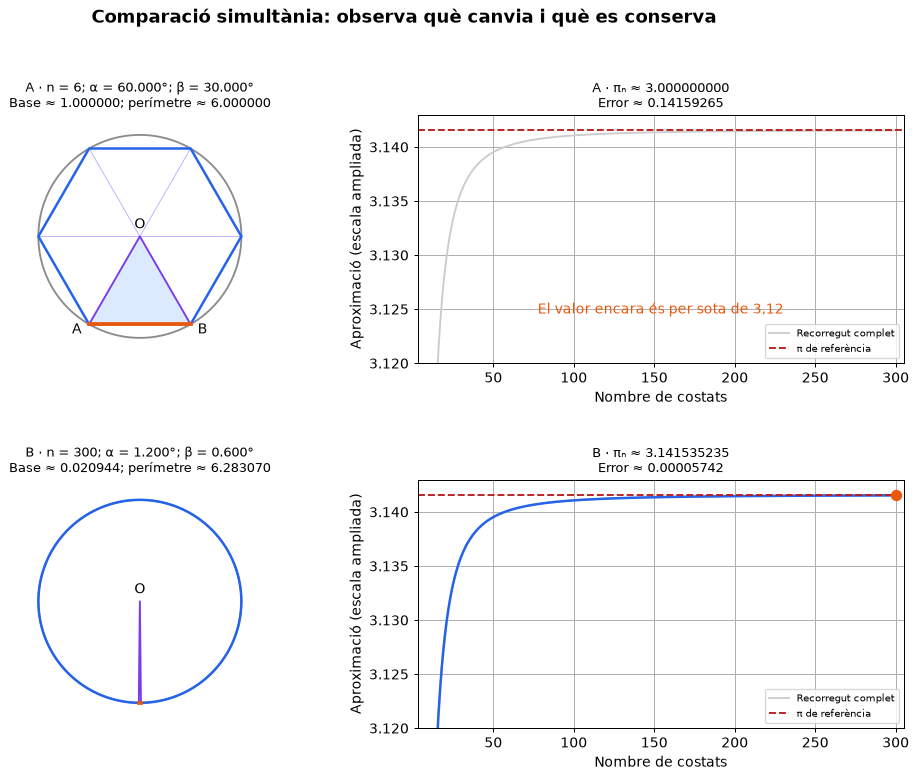

interactive(children=(Dropdown(description='Estat A:', index=3, options=(('3 costats', 3), ('4 costats', 4), (…

In [12]:
compara_estats(*parella_comparacio)
panell_comparacio = controls_comparacio()


### Taller de Python · canvia una dada i explica l'efecte

Mantén el radi fix i compara 30, 60, 120 i 240 costats. Prediu el factor de reducció de l'error quan dupliquem n; després contrasta'l amb els resultats. L'error es calcula amb π només per comprovar l'aproximació.

**Fes-ho en tres passos:** escriu una predicció, modifica les dades indicades i contrasta el resultat. Acaba amb una explicació matemàtica; executar la cel·la és només una part de la tasca.


n= 30; πₙ≈3.135853898; error≈0.005738756
n= 60; πₙ≈3.140157375; error≈0.001435279
n=120; πₙ≈3.141233797; error≈0.000358857
n=240; πₙ≈3.141502937; error≈0.000089716
De 30 a 60: error dividit per 3.9984
De 60 a 120: error dividit per 3.9996
De 120 a 240: error dividit per 3.9999


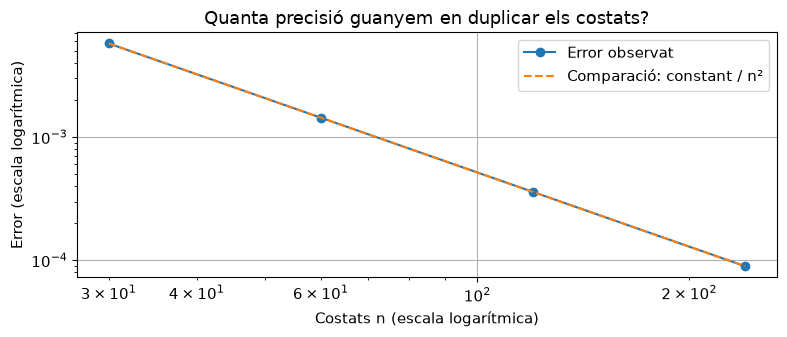

In [13]:
valors_n = [30, 60, 120, 240]
radi_taller = 1
errors_taller = []
for n in valors_n:
    resultat = dades_poligon(n, radi=radi_taller)
    error = math.pi-resultat["pi_aprox"]
    errors_taller.append(error)
    print(f"n={n:3}; πₙ≈{resultat['pi_aprox']:.9f}; error≈{error:.9f}")
for k in range(1, len(valors_n)):
    print(f"De {valors_n[k-1]} a {valors_n[k]}: error dividit per {errors_taller[k-1]/errors_taller[k]:.4f}")
fig, ax = plt.subplots(figsize=(8, 3.5))
ax.loglog(valors_n, errors_taller, "o-", label="Error observat")
ax.loglog(valors_n, [errors_taller[0]*(valors_n[0]/n)**2 for n in valors_n],
          "--", label="Comparació: constant / n²")
ax.set(xlabel="Costats n (escala logarítmica)", ylabel="Error (escala logarítmica)",
       title="Quanta precisió guanyem en duplicar els costats?")
ax.legend(); plt.tight_layout(); plt.show()


### Atura't i comprova què has entès

Tria una resposta per pregunta i escriu una justificació abans de comprovar-la. Si t'equivoques, llegeix el retorn i torna al gràfic per localitzar el malentès.

**1. Amb 12 costats, quin angle usem per calcular mitja base amb el sinus?**

- A. 30°
- B. 15°
- C. 150°

**2. Si el radi es duplica, què passa amb pₙ/(2r)?**

- A. Es conserva
- B. Es duplica
- C. Es divideix per 2

**3. Amb 300 costats, el polígon sembla un cercle. Què significa?**

- A. Ja hem obtingut π exactament
- B. L'error és exactament zero
- C. La resolució del dibuix amaga una diferència petita

Si no es mostren els controls, executa `mostra_feedback(1, 'B')`, canviant el número i la lletra. El retorn comprova l'opció; la justificació escrita s'ha de discutir a classe.


In [14]:
autoavaluacio = crea_autoavaluacio()


### Evidència final de l'aprenentatge

Completa aquestes frases amb un cas concret del taller:

1. **He canviat…**
2. **Esperava que… perquè…**
3. **El resultat ha estat…**
4. **Ara ho explico amb aquesta relació o propietat…**
5. **Un cas en què no puc generalitzar directament és…**

Torna a una pregunta que hagis corregit i explica què has canviat del teu raonament.


### Investiga i transfereix


1. Dibuixa un polígon de 8 costats i un dels seus triangles. Calcula $\alpha$, $\beta$, $b$ i $\pi_8$.
2. Troba a la taula el primer valor **dels que hi apareixen** amb error menor que $0{,}001$.
   Després usa Python per trobar el primer enter entre 3 i 300 que ho compleix.
3. Explica per què una imatge que sembla un cercle no demostra que el polígon sigui un cercle.
4. Canvia el radi a 2: què es duplica i què es conserva?


### El teu raonament

Edita aquesta cel·la per deixar evidència del que has après.

- **Abans pensava que…**
- **He provat aquests valors…**
- **Al gràfic he observat…**
- **Ho justifico amb aquest càlcul o propietat…**
- **La meva conclusió i el seu límit són…**

No n'hi ha prou amb una captura: relaciona el dibuix, els nombres i l'explicació.


In [15]:
# Espai per al teu experiment: canvia l'índex i executa la cel·la.
# fotograma_laboratori(fotogrames_laboratori[0])
# Escriu aquí els càlculs del repte.


<details><summary>Comprovació: obre-la després d'intentar els reptes</summary>

Per a 8 costats: $\alpha=45°$, $\beta=22{,}5°$, $b\approx0{,}76536686$
i $\pi_8\approx3{,}06146746$. La primera fila de la taula que compleix l'error és 96;
examinant tots els enters, és 72. El dibuix té resolució finita. En duplicar el radi,
es dupliquen costat i perímetre, però $p_n/(2r)$ es conserva.

</details>

**Comprova el teu aprenentatge:** has interpretat els eixos i les unitats, justificat una predicció amb un càlcul i aplicat la idea a un cas nou? Una observació finita pot suggerir una propietat; una afirmació general necessita una justificació.


## 5. Experimenta: canvia el nombre de costats

Mou el control de 3 a 300. El punt taronja indica al gràfic l'aproximació del
polígon escollit. Sota el dibuix pots seguir **angle → mitja base → base → perímetre → aproximació**.
Amb molts costats el polígon i el cercle gairebé no es distingeixen; comprova la
diferència numèrica. Si el control no apareix, modifica `n` a la crida següent.


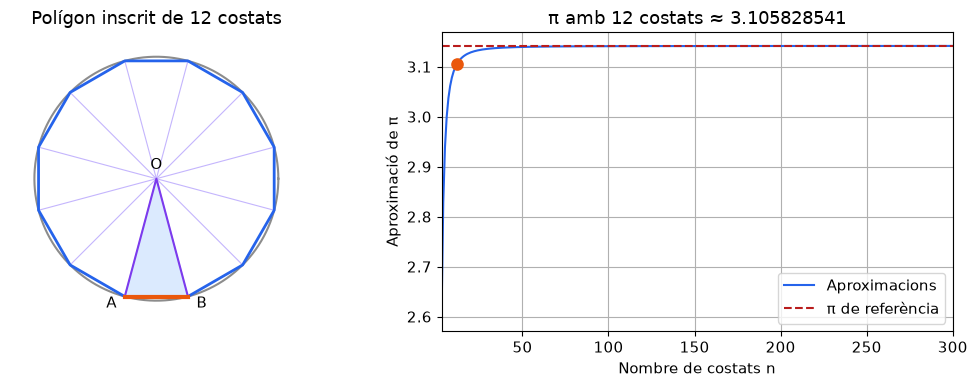

**Amb 12 costats i radi 1:**

1. Angle superior: **360° / 12 = 30.000000°**.
2. Mig angle: **30.000000° / 2 = 15.000000°**.
3. Mitja base: **sin(15.000000°) ≈ 0.258819045**.
4. Base completa: **2 × 0.258819045 ≈ 0.517638090**.
5. Perímetre: **12 × 0.517638090 ≈ 6.211657082**.
6. Aproximació de π: **6.211657082 / 2 ≈ 3.105828541**.

Error respecte al valor de referència: **0.035764112**. Els valors mostrats s'han arrodonit; el càlcul conserva tots els decimals.

In [16]:
def explora_aproximacio(n=12):
    d = dades_poligon(n)
    fig, (ax, bx) = plt.subplots(1, 2, figsize=(11, 4))
    dibuixa_poligon(ax, n)
    ax.set_title(f"Polígon inscrit de {n} costats")
    bx.plot(costats, aproximacions, color="#2563eb", label="Aproximacions")
    bx.axhline(math.pi, color="#b91c1c", ls="--", label="π de referència")
    bx.scatter([n], [d["pi_aprox"]], color="#ea580c", s=65, zorder=5)
    bx.set(xlim=(3, 300), xlabel="Nombre de costats n", ylabel="Aproximació de π",
           title=f"π amb {n} costats ≈ {d['pi_aprox']:.9f}")
    bx.legend(loc="lower right")
    fig.tight_layout()
    plt.show()
    display(Markdown(
        f"**Amb {n} costats i radi 1:**\n\n"
        f"1. Angle superior: **360° / {n} = {d['alpha']:.6f}°**.\n"
        f"2. Mig angle: **{d['alpha']:.6f}° / 2 = {d['beta']:.6f}°**.\n"
        f"3. Mitja base: **sin({d['beta']:.6f}°) ≈ {d['base']/2:.9f}**.\n"
        f"4. Base completa: **2 × {d['base']/2:.9f} ≈ {d['base']:.9f}**.\n"
        f"5. Perímetre: **{n} × {d['base']:.9f} ≈ {d['perimetre']:.9f}**.\n"
        f"6. Aproximació de π: **{d['perimetre']:.9f} / 2 ≈ {d['pi_aprox']:.9f}**.\n\n"
        f"Error respecte al valor de referència: **{math.pi-d['pi_aprox']:.9f}**. "
        "Els valors mostrats s'han arrodonit; el càlcul conserva tots els decimals."
    ))

# Exemple visible també en lectors que no mostren controls interactius.
explora_aproximacio(n=12)


In [17]:
try:
    import ipywidgets as widgets
except ImportError:
    print("Pots explorar altres valors executant explora_aproximacio(n=300).")
else:
    control = widgets.IntSlider(value=12, min=3, max=300, step=1,
                                description="Costats n:", continuous_update=False)
    panell = widgets.interactive(explora_aproximacio, n=control)
    display(panell)


interactive(children=(IntSlider(value=12, continuous_update=False, description='Costats n:', max=300, min=3), …

## 6. Ampliació: aproximar per sota i per sobre

Un polígon **circumscrit** té els costats tangents a la circumferència.
Si el seu perímetre és $P_n$, la comparació geomètrica dona
$p_n<2\pi<P_n$ per a radi 1. Dividint per 2:

$$L_n=\frac{p_n}{2}<\pi<\frac{P_n}{2}=U_n.$$

Per a l'hexàgon, $L_6=3$ i $U_6=2\sqrt3$. L'algorisme d'Arquimedes duplica
els costats amb arrels quadrades i operacions aritmètiques. En aquest apartat
comparem $6,12,24,\ldots,192$ costats; el gràfic anterior sí que inclou **tots**
els enters fins a 300. Estudiarem la recurrència al quadern següent.

Les cotes geomètriques exactes encerclen π; el programa en mostra valors arrodonits.


In [18]:
def arquimedes(passos=8, precisio=60):
    """Semiperímetres calculats amb Decimal; les xifres tenen arrodoniment."""
    if not isinstance(passos, int) or passos < 0:
        raise ValueError("El nombre de passos ha de ser un enter no negatiu.")
    if not isinstance(precisio, int) or precisio < 16:
        raise ValueError("Calen almenys 16 xifres de precisió.")
    with localcontext() as ctx:
        ctx.prec = precisio
        n, inferior, superior = 6, Decimal(3), 2 * Decimal(3).sqrt()
        files = [(n, inferior, superior)]
        for _ in range(passos):
            nova_superior = 2 * inferior * superior / (inferior + superior)
            nova_inferior = (inferior * nova_superior).sqrt()
            n, inferior, superior = 2 * n, nova_inferior, nova_superior
            files.append((n, inferior, superior))
    return files


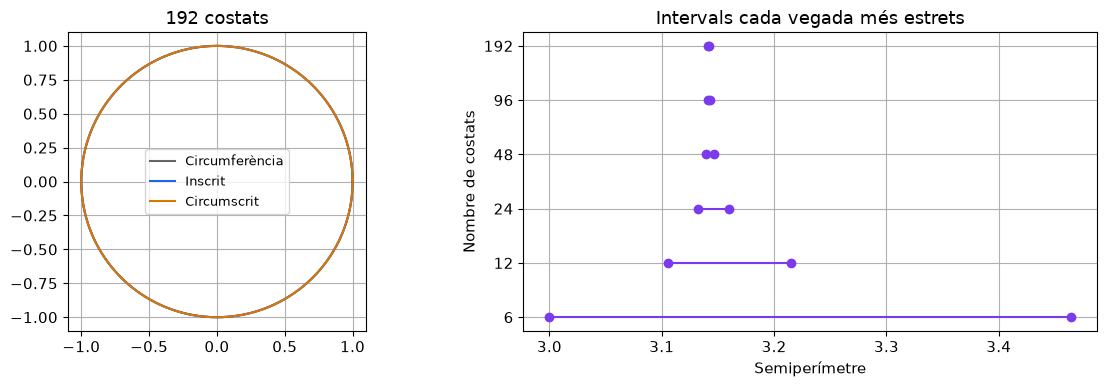

Cota inferior ≈ 3.141452472285; cota superior ≈ 3.141873049980
Amplada aproximada: 4.2058E-4


In [19]:
def poligons(iteracions=2):
    n, inferior, superior = arquimedes(iteracions)[-1]
    fig, (ax, bx) = plt.subplots(1, 2, figsize=(12, 4))
    # Aquestes funcions trigonomètriques només serveixen per dibuixar.
    angles = np.linspace(0, 2*np.pi, n+1)
    t = np.linspace(0, 2*np.pi, 500)
    radi_exterior = 1 / np.cos(np.pi/n)
    ax.plot(np.cos(t), np.sin(t), color="0.4", label="Circumferència")
    ax.plot(np.cos(angles), np.sin(angles), color="#2563eb", label="Inscrit")
    ax.plot(radi_exterior*np.cos(angles+np.pi/n),
            radi_exterior*np.sin(angles+np.pi/n), color="#d97706", label="Circumscrit")
    ax.set_aspect("equal")
    ax.set_title(f"{n} costats")
    ax.legend(fontsize=9)
    files = arquimedes(iteracions)
    for k, (_, a, b) in enumerate(files):
        bx.plot([float(a), float(b)], [k, k], "o-", color="#7c3aed")
    bx.set_yticks(range(len(files)), [str(f[0]) for f in files])
    bx.set(xlabel="Semiperímetre", ylabel="Nombre de costats", title="Intervals cada vegada més estrets")
    fig.tight_layout()
    plt.show()
    print(f"Cota inferior ≈ {inferior:.12f}; cota superior ≈ {superior:.12f}")
    print(f"Amplada aproximada: {superior-inferior:.4E}")

poligons(iteracions=5)


## 7. Què hem après? Aplica-ho

**En cap pas finit el polígon es converteix en la circumferència.** Aproximem π
amb polígons cada vegada més precisos. Una mostra fins a 300 costats permet observar
la tendència, però no és una demostració d'un límit infinit.

1. Per a $n=20$, calcula $\alpha$, $\beta$, $b$, $p_n$ i $\pi_n$, en aquest ordre.
   Dibuixa $O$, $A$, $B$ i $M$ i indica on hi ha $b/2$.
2. Un alumne escriu $b=\sin(360^\circ/n)$ quan $r=1$. Explica **els dos errors**.
3. Compara les files de 6, 48 i 300 costats: què passa amb la base, amb el perímetre
   i amb l'error? Per què una base més petita no implica un perímetre més petit?
4. Amb 300 costats, hem trobat π o una aproximació? Per què necessitem l'ampliació
   del gràfic i la columna de l'error?
5. **Ampliació:** executa `dades_poligon(20, radi=3)`. Què es multiplica per 3?
   Per què l'aproximació de π és la mateixa?
6. **Ampliació:** si $L_n<\pi<U_n$, justifica que el punt mig $(L_n+U_n)/2$
   té un error menor que $(U_n-L_n)/2$ (amb les cotes exactes).

<details><summary>Pistes i comprovació després d'intentar-ho</summary>

1. $\alpha=18^\circ$, $\beta=9^\circ$, $b\approx0{,}31286893$,
   $p_{20}\approx6{,}25737860$, $\pi_{20}\approx3{,}12868930$.
2. Cal utilitzar **mig angle**, $180^\circ/n$, i multiplicar per **2** per passar
   de mitja base a la base completa.
3. La base disminueix, el perímetre augmenta i l'error disminueix: el nombre de
   costats també augmenta i cal considerar el producte $n b$.
4. És una aproximació; a l'escala del dibuix dues línies poden semblar coincidents.
5. Base i perímetre es tripliquen; en dividir per $2r=6$, la proporció es conserva.
6. La distància del punt mig a qualsevol punt interior és menor que la meitat
   de l'amplada de l'interval.

</details>

**Cap al quadern següent.** Podem reduir l'amplada dels intervals tant com vulguem?
Què garanteix que determinen un únic nombre real? Aquestes preguntes ens conduiran
a l'algorisme d'Arquimedes i a la completesa de ℝ.


**Navegació:** [Anterior](Q_conjunt_dens.ipynb) · [Índex i guia](README.md) · [Següent](NumeroPi.ipynb)
